# Model Integration Workflow Demo

This notebook provides a **demonstration and case study of the model integration workflow**, showing how to connect **external models**—such as pilot-scale experimental data or rigorous process simulators—into WaterTAP.  

The workflow illustrates how surrogate modeling can bridge detailed models with **system-scale analysis**, enabling:  
- Technology performance screening  
- Process integration and plant-wide optimization  
- Techno-economic and market participation assessments,  
  which are **enabled capabilities within the WaterTAP and IDAES ecosystem**.  

**Example Case:**  
In this demonstration, we integrate the **Modular Encapsulated Two-Stage Anaerobic Biological (METAB) system**. The workflow was implemented to connect:  
- **Benchmark Simulation Model in WaterTAP**  
- **Rigorous METAB process model** developed in the study by:  

> Zhang, X., Arnold, W. A., Wright, N., Novak, P. J., & Guest, J. S. (2024). *Prioritization of early-stage research and development of a hydrogel-encapsulated anaerobic technology for distributed treatment of high strength organic wastewater.* Environmental Science & Technology, 58(44), 19651–19665.  

The model was implemented on the external modeling platform [QSDsan](https://qsdsan.com/) (Quantitative Sustainable Design for Sanitation & Resource Recovery Systems), an open-source platform that integrates system design, process modeling & simulation, techno-economic analysis, and life-cycle assessment.  

This example illustrates how external models can be systematically integrated into WaterTAP to enable **system-scale evaluation, optimization, and techno-economic analysis** of novel wastewater treatment technologies.

![Easy Five-Step Workflow: Variables --> Input Space --> Model Runs --> Surrogate --> Selection](model_integration_workflow_steps.png)

## Step 1: Define Input Variables

The first step in the workflow is to **select the key operating and design variables** that will define the input space for surrogate modeling.  

**Example Case: METAB System**  
For the METAB system, the input variables of interest include:  
- **Influent flow rate (loading rate)** – the rate at which wastewater enters the system  
- **Operational temperature** – affects microbial activity and treatment efficiency  
- **Hydraulic Retention Time (HRT)** – the time wastewater remains in the digester, influencing conversion and biogas production  

**Steps:**  
- Select **key operating/design variables** relevant to system performance  
- Establish **bounds for the operational range** based on pilot data or rigorous model knowledge  

These defined variables and bounds form the foundation for **input space generation** in the next step.

In [1]:
input_var_info = {
        "inf_fr": (5000,10000),  # Influent flow rate (loading rate), lower bounds, upper bounds
        "temp": (22, 35),  # Operational temperature
        "hrt": (1, 12),   # Hydraulic Retention Time (HRT)
    }

## Step 2: Input Space Generation

Once the key input variables and their bounds are defined, the next step is to **systematically generate the input space**. This ensures that the surrogate model captures the full variability of the system.  

**Example Case: METAB System**  
For METAB, the input variables include influent flow rate, operational temperature, and HRT. The goal is to explore combinations of these variables across their feasible ranges.  

**Steps:**  
- **Systematically sample operating ranges** to cover variability in the input space  
- **Methods:**  
  - Random sampling within bounds  
  - **Latin Hypercube Sampling (LHS)** – a space-filling statistical technique that divides each variable’s range into intervals and selects samples to evenly cover the multi-dimensional space  
  - Other space-filling designs, as needed  

**Goal:**  
- Generate a **broad and representative dataset** for surrogate model training  
- Ensure that all relevant operating conditions are considered for accurate system-level predictions  

This input dataset will be used in **Step 3: Model Evaluations** to generate outputs for surrogate training.


In [2]:
from watertap.flowsheets.METAB.input_space_generation import create_samples
import os

input_data_csv_file =  "../watertap/flowsheets/METAB/input_data.csv"

if not os.path.exists(input_data_csv_file):
    create_samples(input_var_info=input_var_info,   # defined in step 1
                   sample_numbers=20,               # can be changed to any integer
                   csv_file =input_data_csv_file )
    
print(f"Input data space file has been generated.")

Input data space file has been generated.


## Step 3: External Model Evaluations

In this step, we **run the rigorous external models** to generate outputs for the input conditions sampled in Step 2. These outputs will form the training dataset for surrogate models.  

**Example Case: METAB System**  
For METAB, the external model could be the rigorous process simulation implemented in QSD-SAN. For each combination of influent flow rate, operational temperature, and HRT, the model generates outputs such as:  
- **Biogas production**  
- **Effluent flow rate and quality**  


**Steps:**  
- Run the rigorous model across all sampled input sets  
- Collect model outputs to form a **comprehensive dataset**  
- Ensure that the dataset **captures nonlinear system behavior** across the operational range  

This dataset will then be used in **Step 4: Surrogate Model Training**, bridging the detailed external model with the WaterTAP flowsheet for system-scale analysis.


In [3]:
from watertap.flowsheets.METAB.model_evaluation import get_input_data, run_model, export_output_data 
import os  
import pandas as pd
input_data_csv_file =  "../watertap/flowsheets/METAB/input_data.csv"
output_data_csv_file = "../watertap/flowsheets/METAB/output_data.csv"
if not os.path.exists(output_data_csv_file):
    input_data = get_input_data(filename=input_data_csv_file)
    output_data = run_model(input_data)
    export_output_data(output_data,
                       filename=output_data_csv_file)
print(f"Model evaluation output file has been generated.")

Model evaluation output file has been generated.


## Step 4: Surrogate Model Training

Once the training dataset from Step 3 is available, we fit **surrogate models** to approximate the behavior of the rigorous external model. Surrogates allow fast evaluations while capturing nonlinear relationships between inputs and outputs.

**Example Case: METAB System**  
For METAB, the surrogates predict outputs such as biogas production, effluent quality, and energy consumption based on influent flow rate, operational temperature, and HRT.

---

### Surrogate Model Types

**1. Polynomial Regression**  
Fits a polynomial equation to relate inputs $x_1, x_2, ..., x_n$ to output $y$:  

$$
y = \beta_0 + \sum_{i=1}^{n} \beta_i x_i + \sum_{i=1}^{n}\sum_{j=i}^{n} \beta_{ij} x_i x_j + \epsilon
$$

- $\beta$ are coefficients, $\epsilon$ is error  
- Can include higher-order terms for nonlinearity  

**2. Kriging (Gaussian Process Regression)**  
Models the output as a Gaussian process:  

$$
y(x) = \mu + Z(x)
$$  

Covariance:  

$$
\text{Cov}[Z(x_i), Z(x_j)] = \sigma^2 R(x_i, x_j), \quad
R(x_i, x_j) = \exp\left(-\sum_{k=1}^n \theta_k |x_{ik} - x_{jk}|^2\right)
$$  

- $\mu$ is the mean, $Z(x)$ is a correlated Gaussian process  
- Captures nonlinearities and provides uncertainty estimates  

**3. Radial Basis Function (RBF)**  
Approximates outputs as weighted sums of radial functions:  

$$
y(x) = \sum_{i=1}^{N} w_i \phi(\|x - x_i\|)
$$  

- $x_i$ are training points, $w_i$ are weights  
- $\phi(r)$ is a radial function, e.g., Gaussian: $\phi(r) = e^{-(\epsilon r)^2}$  

**4. ALAMO (Automated Learning of Algebraic Models for Optimization)**  
Constructs simple algebraic models:  

$$
y = \sum_{i} c_i f_i(x)
$$  

- $f_i(x)$ are linear, polynomial, exponential, or rational functions  
- ALAMO selects relevant terms to balance accuracy and simplicity  
- Produces **optimization-ready models**  

---

These surrogate models are **computationally efficient** and ready for validation and selection in Step 5, enabling integration into WaterTAP for system-scale analysis.


In [4]:
import os
import pandas as pd
from idaes.core.surrogate.pysmo_surrogate import PysmoSurrogate
import watertap.flowsheets.METAB.surrogate_model_generator as trainer

feed_data, input_data, output_data = trainer.get_data()
output_data = trainer.outputs_selections(output_data)

# Combine the input and output data
feed_data = pd.concat([input_data, output_data], axis=1)

all_surrogate_methods = ['poly', 'kri', 'rbf', 'alamo']
path = "../watertap/flowsheets/METAB/"

surrogate_objects = {}

for method in all_surrogate_methods:
    model_file = path + method + "_surrogate.json"
    if not os.path.exists(model_file):
        trainer.gen_surrogate_model(
            method=method,
            feed_data=feed_data,
            input_data=input_data,
            output_data=output_data,
        )
    print("Surrogate model using " + method + " method has been generated")

# Load the trained poly surrogate for performance estimation and plotting
poly_surrogate = PysmoSurrogate.load_from_file(path + "poly_surrogate.json")

print("All models are trained and ready for selection")


['S_su', 'S_aa', 'S_fa', 'S_va', 'S_bu', 'S_pro', 'S_ac', 'S_h2', 'S_ch4', 'S_IC', 'S_IN', 'S_I', 'X_c', 'X_ch', 'X_pr', 'X_li', 'X_su', 'X_aa', 'X_fa', 'X_c4', 'X_pro', 'X_ac', 'X_h2', 'X_I', 'S_cat', 'S_an', 'H2O', 'VolumetricFlowrate', 'bge2_S_h2', 'bge2_S_ch4', 'bge2_S_IC', 'bge2_VolumetricFlowrate', 'bgr2_S_h2', 'bgr2_S_ch4', 'bgr2_S_IC', 'bgr2_H2O', 'bgr2_VolumetricFlowrate', 'bge1_S_h2', 'bge1_S_ch4', 'bge1_S_IC', 'bge1_VolumetricFlowrate']
Surrogate model using poly method has been generated
Surrogate model using kri method has been generated
Surrogate model using rbf method has been generated
Surrogate model using alamo method has been generated
2026-05-19 10:05:10 [INFO] idaes.core.surrogate.pysmo_surrogate: Decode surrogate. type=poly

===========================Polynomial Regression===============================================


The number of cross-validation cases (3) is used.
The default training/cross-validation split of 0.75 is used.
No iterations will be run.
Default

# Step 5: Performance Estimation & Model Selection

After training surrogate models in Step 4, the next step is to **validate their accuracy** and select the best-performing model for system-scale integration.

**Example Case: METAB System**  
For METAB, surrogate models predict outputs like biogas production, effluent quality, and energy consumption. These predictions are compared against a **withheld test dataset** (data not used in training) to evaluate model performance.

**Steps:**  
- **Validate surrogate accuracy** using metrics such as:  
  - **R² (Coefficient of Determination)** – indicates how well the model explains variance in the data  
  - **RMSE (Root Mean Squared Error)** – measures the average prediction error  
  - **Parity plots** – visualize predicted vs. actual values for each output  

- **Select the best-performing surrogate model** based on these metrics  
- The selected surrogate is then **ready to integrate** into WaterTAP for system-level analysis, optimization, and techno-economic evaluation

**Outcome:**  
A computationally efficient surrogate model that faithfully represents the external rigorous model and can be used for **plant-scale simulations and decision-making**.


In [5]:
from watertap.flowsheets.METAB.performance_estimation import display_performance

display_performance(surrogate=poly_surrogate, dataframe=feed_data)


,Predicted Variables,R^2,MAE,MSE,RMSE,Max AE
1,S_su,0.982842,0.251895,1.451095e-01,0.380932,1.117609
2,S_aa,0.990575,0.088737,1.775902e-02,0.133263,0.394994
3,S_fa,0.982444,0.988848,2.254959e+00,1.501652,4.535845
4,S_va,0.992831,0.154351,5.098712e-02,0.225803,0.727281
5,S_bu,0.993203,0.210170,9.303517e-02,0.305017,0.991938
6,S_pro,0.987178,0.324885,2.298348e-01,0.479411,1.417675
7,S_ac,0.989913,0.619289,8.786020e-01,0.937338,2.724243
8,S_h2,0.986690,0.000002,6.255281e-12,0.000003,0.000008
9,S_ch4,0.995764,0.182005,6.960779e-02,0.263833,0.790140
10,S_IC,0.987474,1.304313,3.302947e+00,1.817401,5.160095


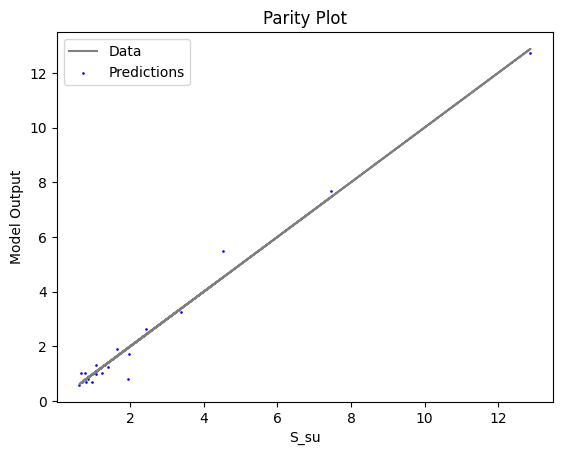

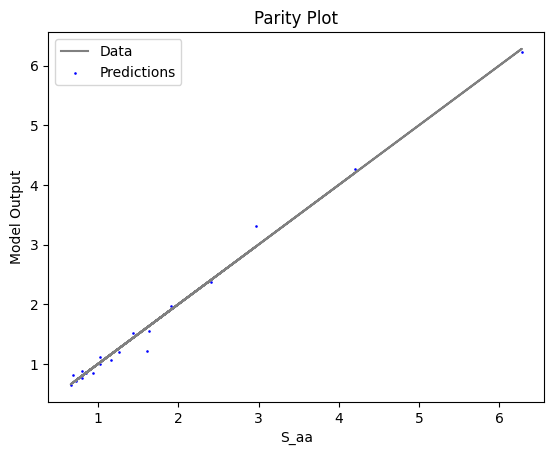

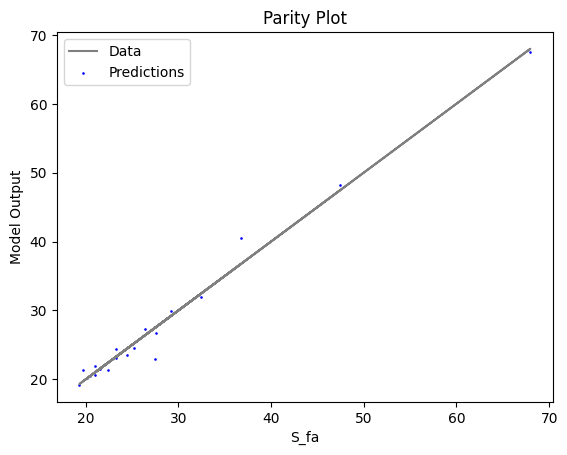

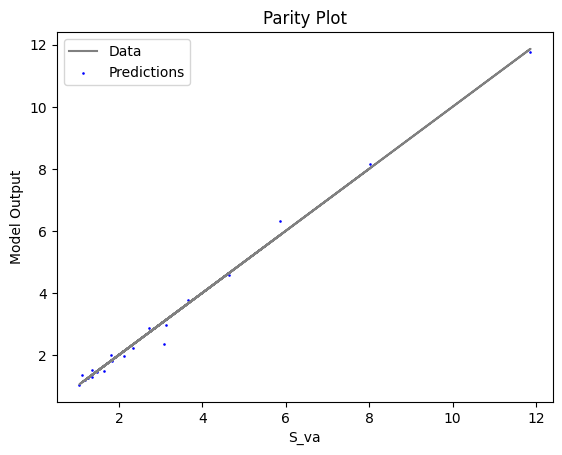

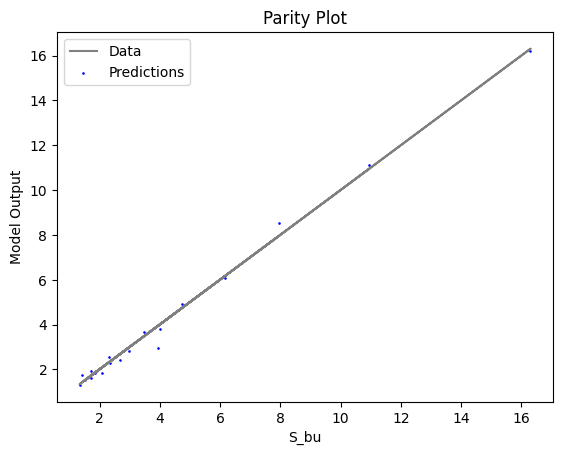

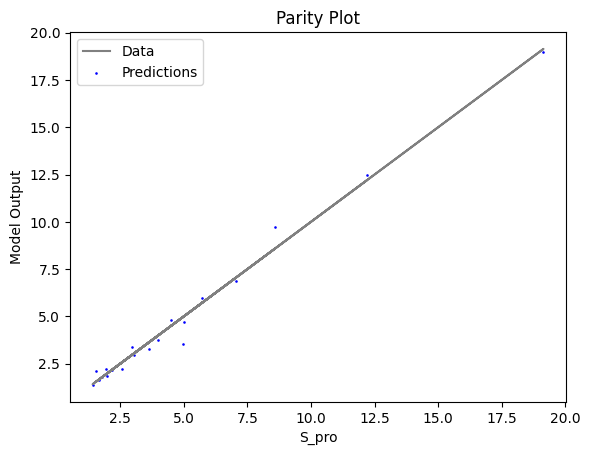

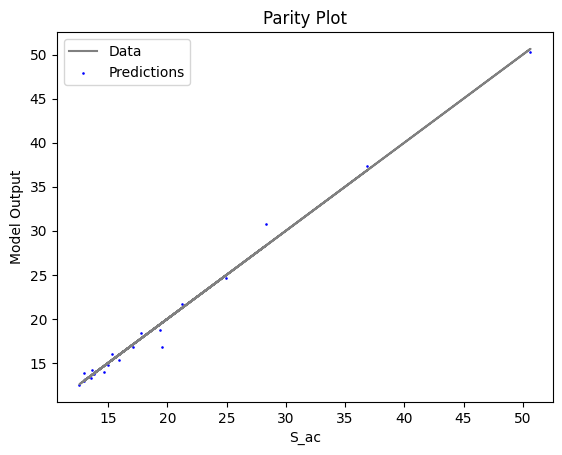

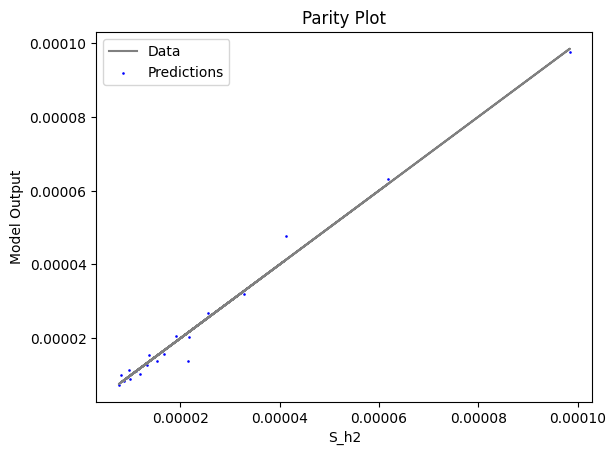

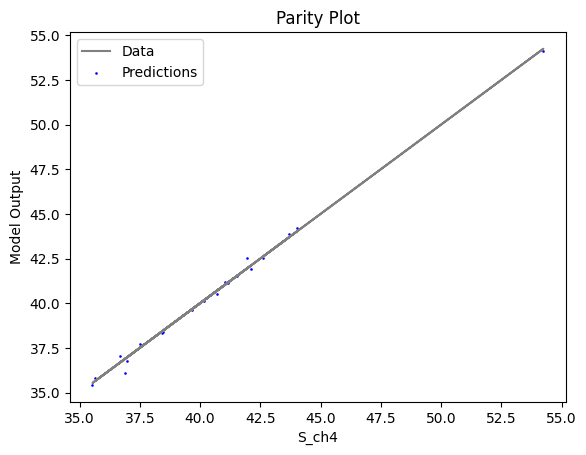

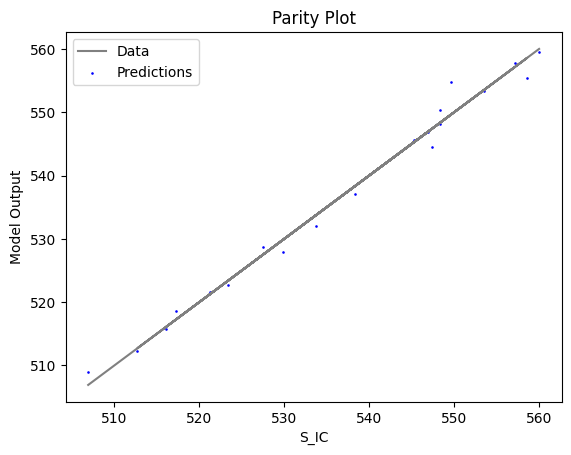

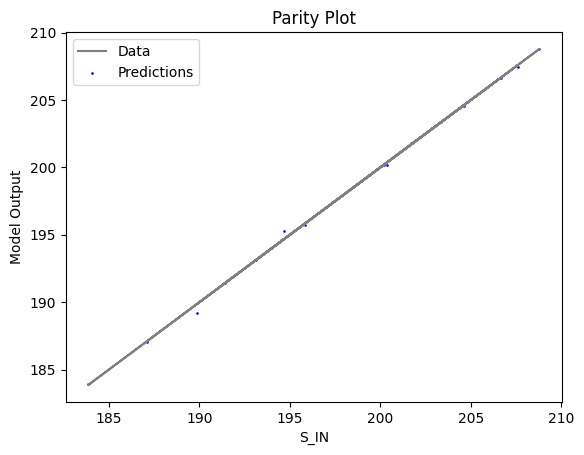

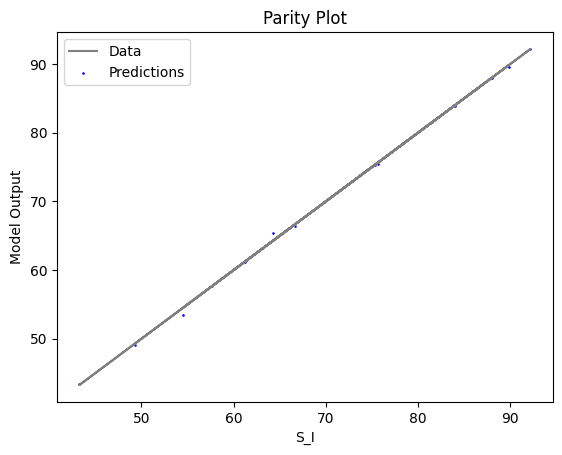

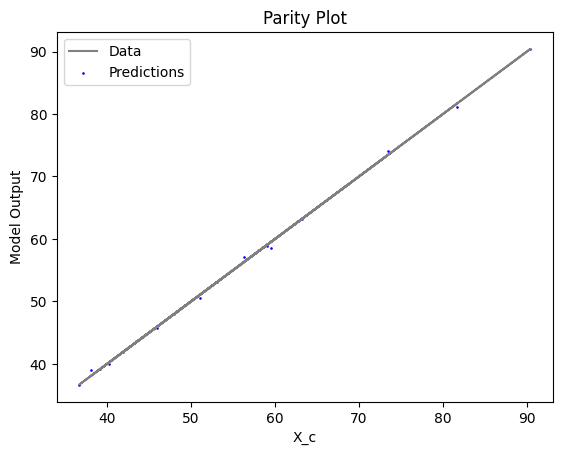

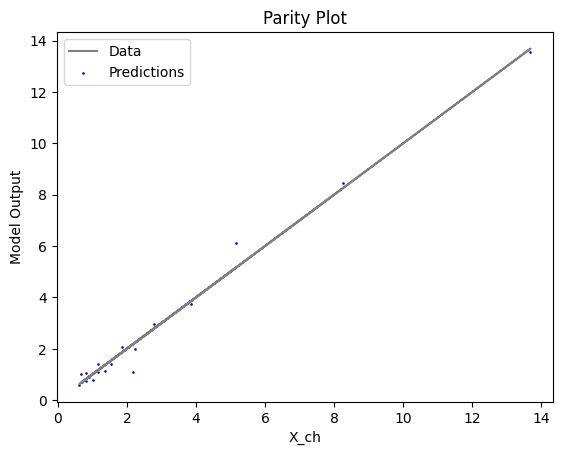

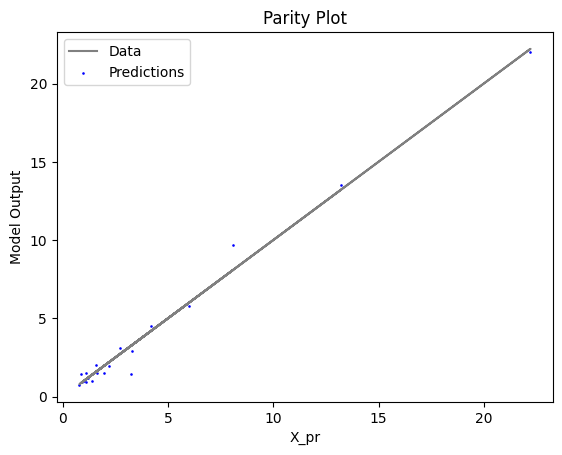

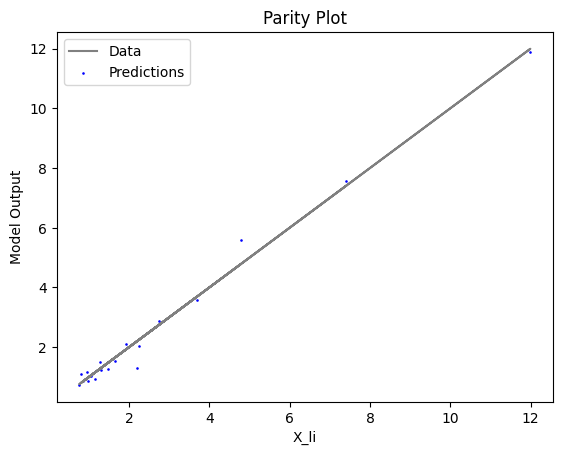

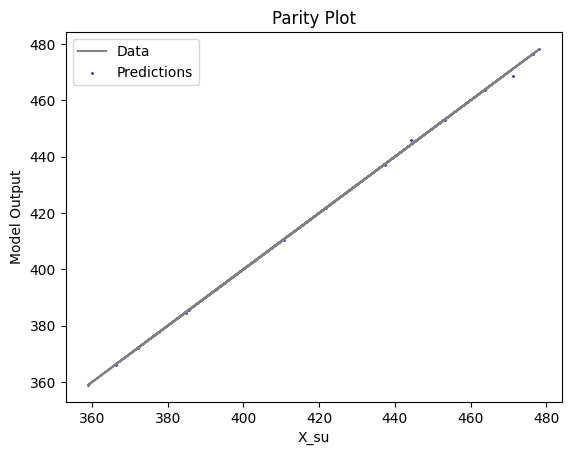

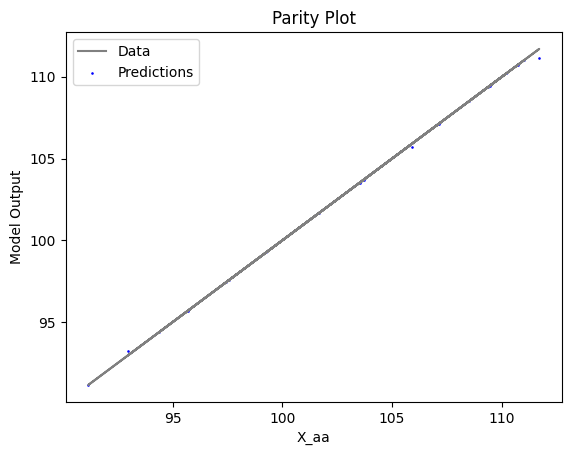

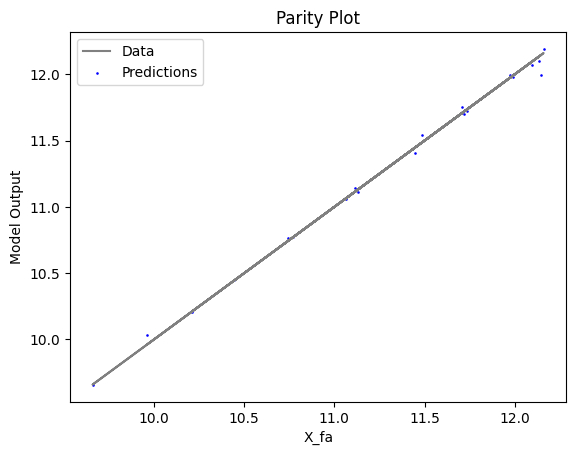

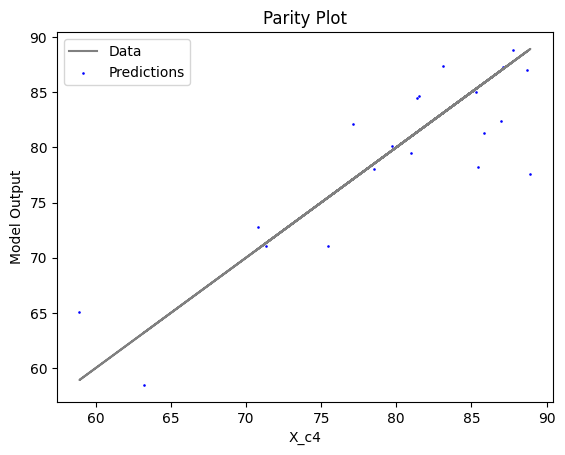

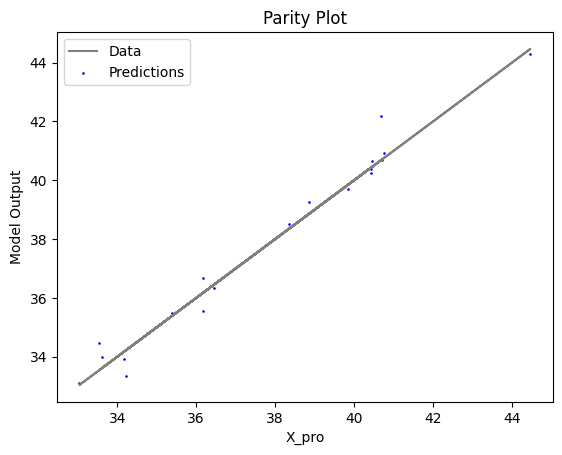

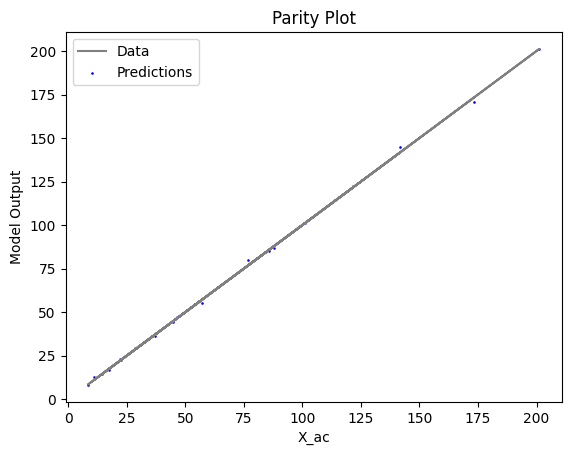

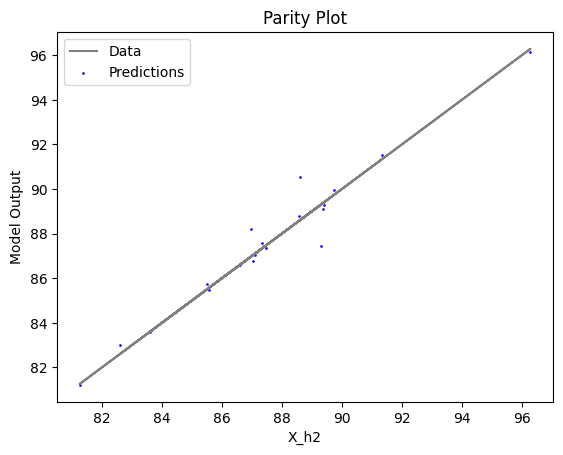

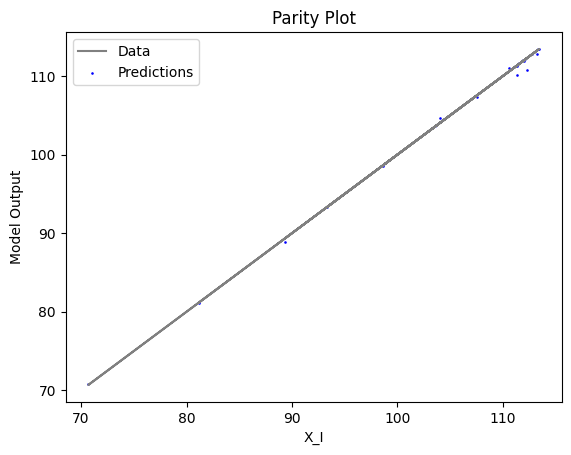

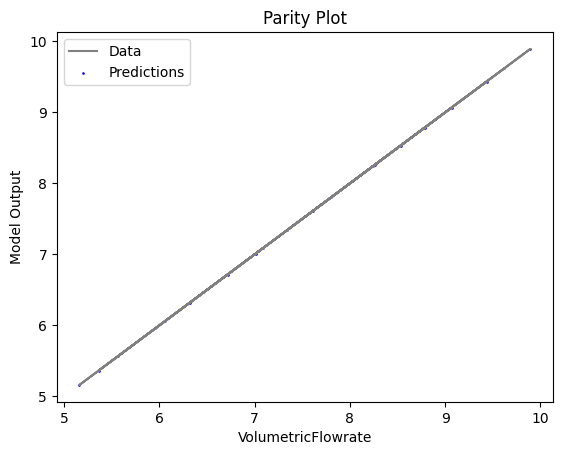

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [6]:
from watertap.flowsheets.METAB.performance_estimation import display_plot

# surrogate and feed_data are set in the training cell above
display_plot(
    surrogate=poly_surrogate,
    dataframe=feed_data,
    method="poly",
    path=path,
    show=True,
)
